## 1. Importación de datos

In [1]:
#Importo librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"


In [2]:
#Importo los datos previamente limpiados en el Challenge Anterior (Ver repositorio TelecomX parte 1)
data=pd.read_csv("TelecomX_Data_Limpia.csv")
data.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
3304,4710-FDUIZ,1,Male,No,Yes,No,56,Yes,Yes,Fiber optic,...,No,No,Yes,Yes,One year,No,Credit card (automatic),100.30,5614.45,3.34
1100,1599-MMYRQ,0,Male,No,Yes,Yes,62,Yes,No,Fiber optic,...,No,No,No,No,One year,Yes,Credit card (automatic),81.45,4983.05,2.72
6049,8570-KLJYJ,0,Female,No,No,No,36,Yes,Yes,DSL,...,No,No,No,No,One year,No,Mailed check,54.45,1893.50,1.82
4173,5899-MQZZL,1,Female,No,No,No,13,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.00,999.45,2.50
4913,6917-FIJHC,0,Female,No,Yes,No,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,26.00,1776.00,0.87


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [4]:
data.describe()

,Churn,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,32.371149,64.761692,2279.734304,2.158675
std,0.441561,24.559481,30.090047,2266.794470,1.003088
min,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,9.000000,35.500000,398.550000,1.180000
50%,0.000000,29.000000,70.350000,1394.550000,2.340000
75%,1.000000,55.000000,89.850000,3786.600000,2.990000
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [5]:
data.describe(include=['O'])

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


## 2. Separación de la variable de respuesta y las variables explicativas.

In [6]:
X = data.drop("Churn", axis = 1) #conjunto de entrenamiento
y = data["Churn"] #conjunto de prueba

## 3. Transformación de datos para el modelo.

3.1. Variables explicativas (x)



Ahora realizaré las transformaciones pertinentes para que los datos puedan ser leídos por mis modelos.

#### 3.1.1. Eliminación de variables innecesarias.

In [7]:
X = X.drop(['customerID'], axis=1)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [8]:
# #vi en esta matriz de correlación que cuentas_diarias (cuando existá en el encoder) podía causar colinearidad, por tanto, la eliminé
# import pandas as pd

# corr_matrix = X_Encoded[['remainder__Charges.Monthly', 'remainder__Charges.Total',
#        'remainder__Cuentas_Diarias']].corr()
# print(corr_matrix)

In [9]:
X = X.drop(['Cuentas_Diarias'], axis=1)

#### 3.1.2. Transformación de variables categóricas con One Hot Encoder

In [10]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [11]:
columnas = X.columns
columnas

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [12]:
#selecciono las variables categóricas de tipo object para hacer One Hot Encoder
categoricas = X.select_dtypes(include="object").columns
categoricas

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [13]:
#preparo el transformer
one_hot = make_column_transformer(
    (OneHotEncoder(drop="if_binary"), categoricas),
    remainder="passthrough"
)


In [14]:
#ajusto el one hot encoder
X = one_hot.fit_transform(X)

In [15]:
#guardo en un data frame para verificar cómo se ven mis datos ya pasados por el one hot encoder
X_Encoded = pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas))
X_Encoded.head()

,onehotencoder__gender_Male,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,...,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__tenure,remainder__Charges.Monthly,remainder__Charges.Total
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.6,593.30
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.9,542.40
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.9,280.85
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.0,1237.85
4,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.9,267.40


En la siguiente matriz de correlación, valores cercanos a 1, de color rojo indican mayor correlación con el estímulo asociado.

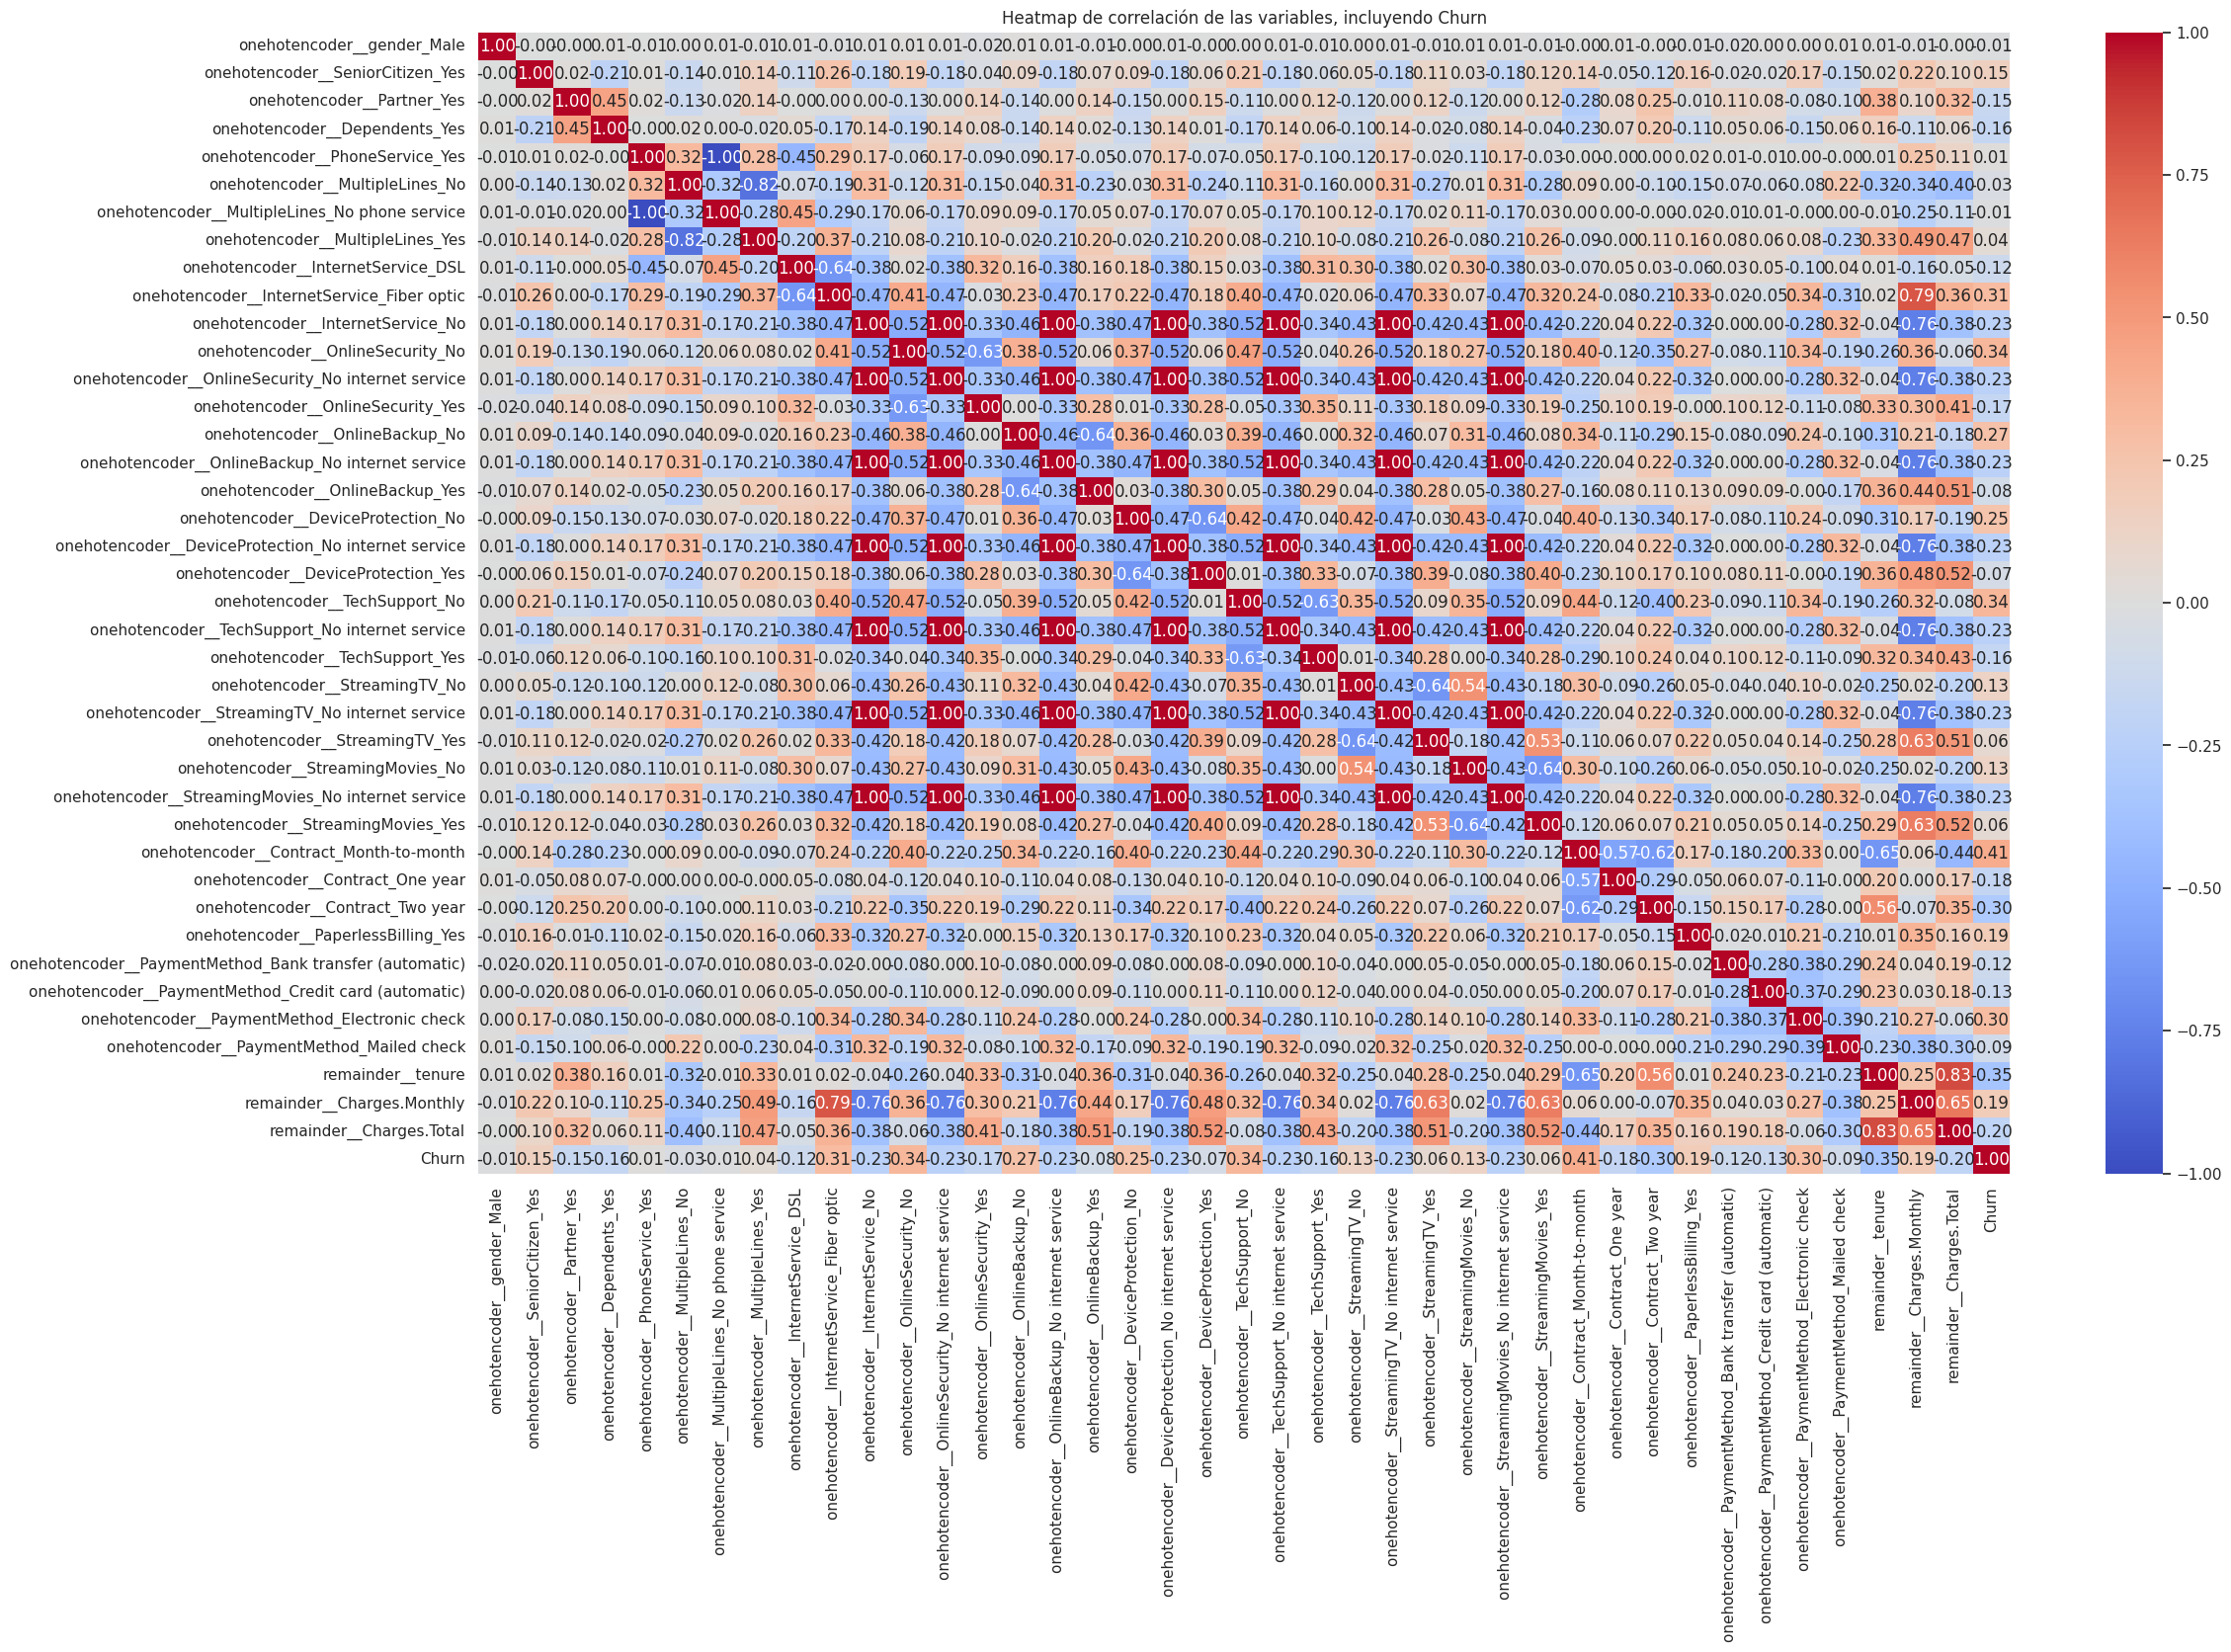

In [46]:
df_corr = pd.concat([X_Encoded, y], axis=1)
plt.figure(figsize=(25,15))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f",)
plt.title("Heatmap de correlación de las variables, incluyendo Churn")
plt.show()

### 3.2. Variable de respuesta (y)

Como ya están binarizados mis datos de y, ya no necesito aplicar el label Encoder para mi variable de respuesta. Sin embargo, dejo la columna comentada con el procedimiento, por si en un futuro llegara a requerirlo.

In [17]:
# from sklearn.preprocessing import LabelEncoder
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)

## Verificación de la proporción de Abandono (Churn)

In [18]:
data["Churn"].value_counts(normalize = True) #ver el porcentaje de esta proporción

,proportion
Churn,
0,0.73463
1,0.26537


Los datos están desbalanceados.

## 4. División de datos en entrenamiento, validación y prueba

Decidí separar una porción de los datos para validación porque es importante para poder probar distintos modelos sin llegar a mostrar los datos de prueba, y así asegurar una mejora en mis evaluaciones.

#### Función para hacer splits del data set

In [19]:
def split_dataset(X, y, test_size, random_state):
    """
    Hace un split train/val/test y devuelve los conjuntos listos.
    """
    from sklearn.model_selection import train_test_split

    # Separar test
    X,X_test,y,y_test = train_test_split(X,y,test_size=test_size,stratify=y,random_state=random_state)

    # Separar val sobre lo que quedó de train
    X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=random_state)

    return X_train, X_val, X_test, y_train, y_val, y_test

**Ejemplo de uso**


```
 X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y, test_size=0.15, val_size=0.25, random_state=22)
```



In [20]:
#defino mis variables de split llamando a la función
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y, test_size=0.15, random_state=22)

## 5. Modelado de los datos

Organicé los procesos de modelado y verificación de datos en funciones, que se pueden usar en todos los modelos que guste probar. Esto para automatizar y limpiar el código.

#### Función para cross-validation

In [21]:
def cross_validate_model(model, X_train, y_train, cv_splits, random_state, scoring):
    """
    Calcula CV y devuelve métricas promedio de train y validation.
    """
    from sklearn.model_selection import cross_validate, KFold
    import numpy as np

    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    results = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring, return_train_score=True)

    return {
        'cv_train_mean': np.mean(results['train_score']),
        'cv_train_std': np.std(results['train_score']),
        'cv_val_mean': np.mean(results['test_score']),
        'cv_val_std': np.std(results['test_score'])
    }

**Ejemplo de uso**



```
from sklearn.tree import DecisionTreeClassifier

# Modelo ya creado
model = DecisionTreeClassifier(max_depth=10, min_samples_split=2)

cv_metrics = cross_validate_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    cv_splits=5,
    random_state=22,
    scoring='accuracy'
)

print(cv_metrics)
```



#### Función para hacer exploración de los parámetros con cross-validation interna

In [22]:
def select_and_validate_model(model_class, param_grid,
                              X_train, y_train, cv_splits,
                              scoring, random_state, model_name):

    """
    Realiza Grid Search con Cross Validation interna y devuelve el mejor modelo entrenado sobre train completo.

    Parámetros:
    - model_class: la clase del modelo (ej: RandomForestClassifier)
    - param_grid: diccionario con las combinaciones de hiperparámetros
    - X_train, y_train: datos de entrenamiento
    - cv_splits: número de folds para CV
    - scoring: métrica para elegir el mejor modelo
    - random_state: semilla reproducible
    - model_name: nombre para reportes

    Devuelve:
    - best_model: modelo entrenado con los mejores parámetros sobre X_train
    - best_params: diccionario de los mejores hiperparámetros
    - cv_results_df: DataFrame con métricas de todas las combinaciones probadas

    El tipo de normalización se determina automáticamente según el modelo.
    """

    from sklearn.model_selection import ParameterGrid, cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    import pandas as pd
    import numpy as np

    # detectar tipo de modelo
    model_name_internal = model_class.__name__

    if model_name_internal in ["LogisticRegression", "SVC", "LinearSVC"]:
        scaler = StandardScaler()

    elif model_name_internal in ["KNeighborsClassifier"]:
        scaler = MinMaxScaler()

    else:
        scaler = None

    grid = list(ParameterGrid(param_grid))
    results = []

    print(f"=== Grid Search para {model_name}: {len(grid)} combinaciones ===")

    for i, params in enumerate(grid):

        # crear modelo con o sin scaler
        if scaler is not None:
            model = Pipeline([
                ("scaler", scaler),
                ("model", model_class(**params))
            ])
        else:
            model = model_class(**params)

        # cross validation
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv_splits,
            scoring=scoring
        )

        mean_score = np.mean(scores)
        std_score = np.std(scores)

        results.append({
            "params": params,
            "cv_mean": mean_score,
            "cv_std": std_score
        })

        print(f"Combinación {i+1}: {params} → CV {scoring}={mean_score:.4f} ± {std_score:.4f}")

    cv_results_df = pd.DataFrame(results)

    best_idx = cv_results_df["cv_mean"].idxmax()
    best_params = cv_results_df.loc[best_idx, "params"]

    print(f"\nMejor combinación encontrada: {best_params} → CV {scoring}={cv_results_df.loc[best_idx,'cv_mean']:.4f}")

    # entrenar modelo final
    if scaler is not None:

        best_model = Pipeline([
            ("scaler", scaler),
            ("model", model_class(**best_params))
        ])

    else:

        best_model = model_class(**best_params)

    best_model.fit(X_train, y_train)

    return best_model, best_params, cv_results_df

**Ejemplo de uso**


```
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10],
    'min_samples_split': [2, 4]
}

best_model_rf, best_params_rf, cv_results_rf = select_and_validate_model(
    model_class=RandomForestClassifier,
    param_grid=param_grid_rf,
    X_train=X_train,
    y_train=y_train,
    cv_splits=5,
    scoring='accuracy',
    random_state=22,
    model_name="RandomForest"
)

print("Mejores parámetros:", best_params_rf)
```



#### Función para entrenamiento y evaluación final del modelo

In [23]:
def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Entrena el modelo y calcula métricas completas, reportes y matrices de confusión.
    """

    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
        classification_report, ConfusionMatrixDisplay
    )
    import matplotlib.pyplot as plt

    print(f"\n===== Evaluando modelo: {model_name} =====")

    # Entrenamiento
    model.fit(X_train, y_train)

    # Reporte textual de accuracy
    print(f"Train Accuracy: {model.score(X_train, y_train):.4f}")
    print(f"Validation Accuracy: {model.score(X_val, y_val):.4f}")

    # Predicciones
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Métricas avanzadas
    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)[:,1]
        y_test_proba = model.predict_proba(X_test)[:,1]
        val_roc = roc_auc_score(y_val, y_val_proba)
        test_roc = roc_auc_score(y_test, y_test_proba)
    else:
        val_roc = test_roc = None

    # Métricas tradicionales
    metrics_val = {
        'accuracy': accuracy_score(y_val, y_val_pred),
        'precision': precision_score(y_val, y_val_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_val, y_val_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_val, y_val_pred, average='weighted', zero_division=0),
        'roc_auc': val_roc
    }

    metrics_test = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'roc_auc': test_roc
    }

    # Classification reports
    print("\nClassification Report - Validation:")
    print(classification_report(y_val, y_val_pred, zero_division=0))
    print("Classification Report - Test:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Matrices de confusión
    print("Confusion Matrix - Validation:")
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
    plt.show()
    print("Confusion Matrix - Test:")
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.show()

    return metrics_val, metrics_test

**Ejemplo de uso**



```
metrics_val_rf, metrics_test_rf = train_and_evaluate(
    best_model_rf,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    model_name="RandomForest_Final"
)

print("Métricas final en Test:", metrics_test_rf)
```



#### Función para graficar comparativos de métricas entre modelos

In [24]:
def plot_model_results(df_results):
    """
    Genera gráficos comparativos de métricas para varios modelos.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    sns.set(style="whitegrid")

    metrics = [col for col in df_results.columns if col != 'model']
    df_plot = df_results.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='score')

    plt.figure(figsize=(12,6))
    sns.barplot(x='model', y='score', hue='metric', data=df_plot)
    plt.ylim(0,1)
    plt.title("Comparación de métricas por modelo")
    plt.show()

#### Función que hace split, evalúa, hace grid_search y CV, train final y evaluación final y grafica resultados, para varios modelos a la vez

In [25]:
def full_pipeline(models_dict, X, y, test_size, cv_splits, scoring, random_state):
    """
    Pipeline completo para evaluar varios modelos con Grid Search y Cross Validation.

    models_dict: dict
        Clave = nombre del modelo
        Valor = dict con 'class' (clase del modelo) y 'param_grid' (diccionario de hiperparámetros)

    Devuelve:
        df_results: DataFrame con todas las métricas y mejores parámetros
    """
    import pandas as pd

    # 1️⃣ Split dataset
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y, test_size=test_size, random_state=random_state)

    all_results = []

    # 2️⃣ Iterar sobre modelos
    for name, model_info in models_dict.items():
        model_class = model_info['class']
        param_grid = model_info['param_grid']

        print(f"\n=== Evaluando modelo: {name} ===")

        # 2a. Grid Search con CV interna
        best_model, best_params, cv_results = select_and_validate_model(
            model_class,
            param_grid,
            X_train, y_train,
            cv_splits=cv_splits,
            scoring=scoring,
            random_state=random_state,
            model_name=name
        )

        # 2b. Train final y evaluación sobre val/test
        metrics_val, metrics_test = train_and_evaluate(
            best_model,
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            model_name=f"{name}_Final"
        )

        # 2c. Guardar resultados en lista
        all_results.append({
            'model': name,
            'best_params': best_params,
            'cv_mean': cv_results['cv_mean'].max(),
            'cv_std': cv_results['cv_std'][cv_results['cv_mean'].idxmax()],
            'val_accuracy': metrics_val['accuracy'],
            'val_f1': metrics_val['f1'],
            'val_roc_auc': metrics_val['roc_auc'],
            'test_accuracy': metrics_test['accuracy'],
            'test_f1': metrics_test['f1'],
            'test_roc_auc': metrics_test['roc_auc']
        })

    # 3️⃣ Convertir resultados a DataFrame
    df_results = pd.DataFrame(all_results)

    # 4️⃣ Graficar resultados (opcional)
    plot_model_results(df_results)

    return df_results

**Ejemplo de uso**



```
from sklearn.tree import DecisionTreeClassifier

models_dict = {
    'DecisionTree': {
        'class': DecisionTreeClassifier,
        'param_grid': {
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 4],
            'min_samples_leaf': [1, 2]
        }
    },
    'RandomForest': {
        'class': RandomForestClassifier,
        'param_grid': param_grid_rf
    }
}

df_results = full_pipeline(models_dict, X, y, test_size=0.15, val_size=0.25, cv_splits=5, scoring='accuracy')
print(df_results)
```



#### Función full_pipeline simplificada, que omite el grid search y validación cruzada. Hace la comparativa de modelos previamente verificados

In [26]:
def full_pipeline_simple(models_dict, X, y, test_size, random_state):
    """
    Pipeline para varios modelos ya instanciados (Grid Search ya hecho).

    models_dict: dict
        Clave = nombre del modelo (se usará como model_name)
        Valor = objeto modelo instanciado ya optimizado

    Devuelve:
        df_results: DataFrame con métricas y mejores modelos
    """
    import pandas as pd

    # 1️⃣ Split dataset
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y, test_size=test_size, random_state=random_state)

    all_results = []

    # 2️⃣ Iterar sobre modelos
    for name, model in models_dict.items():
        print(f"\n=== Evaluando modelo: {name} ===")

        # Train & Evaluate
        metrics_val, metrics_test = train_and_evaluate(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            model_name=name  # automáticamente usa la clave del dict
        )

        # Guardar resultados
        all_results.append({
            'model': name,
            'val_accuracy': metrics_val['accuracy'],
            'val_f1': metrics_val['f1'],
            'val_roc_auc': metrics_val['roc_auc'],
            'test_accuracy': metrics_test['accuracy'],
            'test_f1': metrics_test['f1'],
            'test_roc_auc': metrics_test['roc_auc']
        })

    # 3️⃣ Convertir resultados a DataFrame
    df_results = pd.DataFrame(all_results)

    # 4️⃣ Graficar resultados (opcional)
    plot_model_results(df_results)

    return df_results



####Función rápida para normalizar datos

La función train_and_evakuate ya normaliza los datos según el tipo de modelo que se esté etrenando, pero esta función sirve como herramienta rápida de normalización en caso de que no utilicemos los otros pipelines

**Ejemplo de uso**



```
# Cuando ya tienes los mejores modelos

models_dict_optimized = {
    'DecisionTree': DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1),
    'RandomForest': RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=2)
}

df_results_light = full_pipeline_simple(models_dict_optimized, X, y)
print(df_results_light)
```



### 5.1. Modelo de referencia - Baseline

In [27]:
from sklearn.dummy import DummyClassifier

param_grid_dummy = {
    'strategy': ['most_frequent', 'stratified', 'uniform', 'constant'],
    'constant': [0, 1]
}

best_dummy, best_params_dummy, cv_results_dummy = select_and_validate_model(
    model_class=DummyClassifier,
    param_grid=param_grid_dummy,
    X_train=X_train,
    y_train=y_train,
    cv_splits=5,
    scoring='f1',
    random_state=22,
    model_name="DummyClassifier"
)

print("Mejor DummyClassifier:", best_params_dummy)

=== Grid Search para DummyClassifier: 8 combinaciones ===
Combinación 1: {'constant': 0, 'strategy': 'most_frequent'} → CV f1=0.0000 ± 0.0000
Combinación 2: {'constant': 0, 'strategy': 'stratified'} → CV f1=0.2773 ± 0.0233
Combinación 3: {'constant': 0, 'strategy': 'uniform'} → CV f1=0.3567 ± 0.0176
Combinación 4: {'constant': 0, 'strategy': 'constant'} → CV f1=0.0000 ± 0.0000
Combinación 5: {'constant': 1, 'strategy': 'most_frequent'} → CV f1=0.0000 ± 0.0000
Combinación 6: {'constant': 1, 'strategy': 'stratified'} → CV f1=0.2509 ± 0.0343
Combinación 7: {'constant': 1, 'strategy': 'uniform'} → CV f1=0.3605 ± 0.0144
Combinación 8: {'constant': 1, 'strategy': 'constant'} → CV f1=0.4196 ± 0.0006

Mejor combinación encontrada: {'constant': 1, 'strategy': 'constant'} → CV f1=0.4196
Mejor DummyClassifier: {'constant': 1, 'strategy': 'constant'}



=== Evaluando modelo: DummyClassifier ===

===== Evaluando modelo: DummyClassifier =====
Train Accuracy: 0.2656
Validation Accuracy: 0.2652

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       701
           1       0.27      1.00      0.42       253

    accuracy                           0.27       954
   macro avg       0.13      0.50      0.21       954
weighted avg       0.07      0.27      0.11       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       495
           1       0.27      1.00      0.42       179

    accuracy                           0.27       674
   macro avg       0.13      0.50      0.21       674
weighted avg       0.07      0.27      0.11       674

Confusion Matrix - Validation:


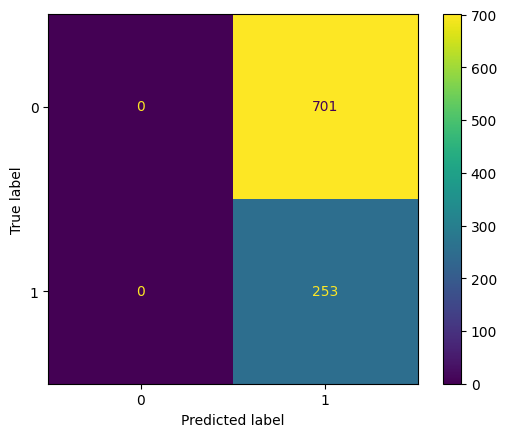

Confusion Matrix - Test:


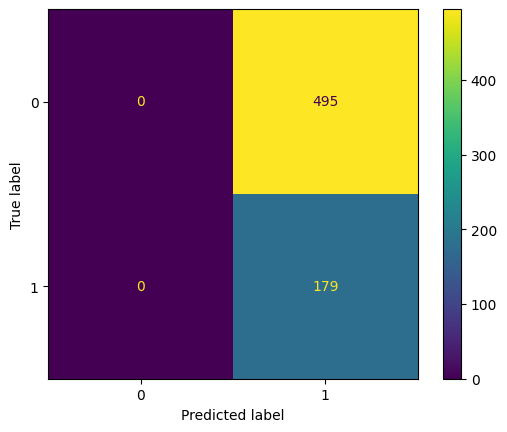

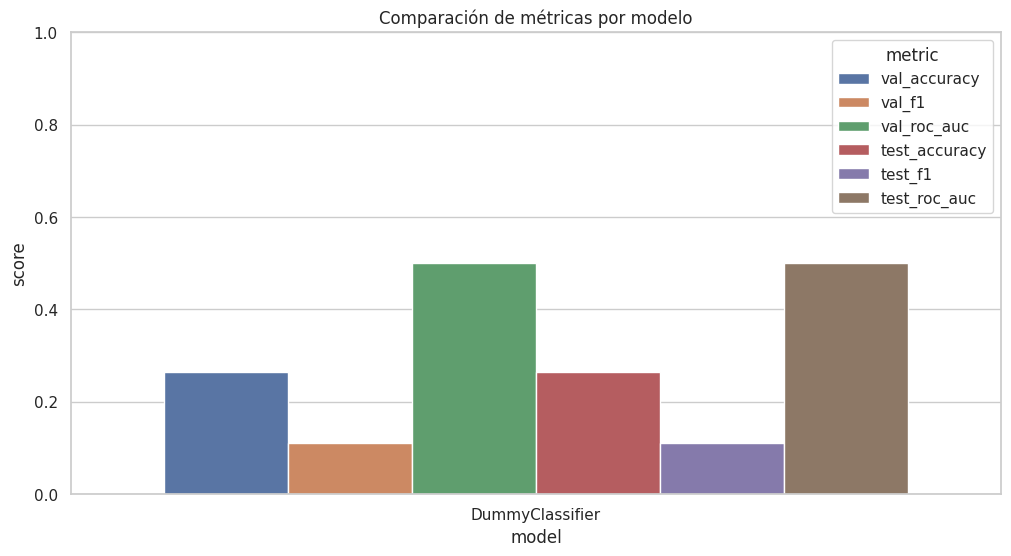

In [28]:
df_results_dummy = full_pipeline_simple({"DummyClassifier": best_dummy}, X_train, y_train, test_size=0.15, random_state = 22)


### 5.2. Modelo Árbol de decisión

In [29]:
from sklearn.tree import DecisionTreeClassifier

param_grid_tree = {
    'max_depth': [4, 5, 6],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

best_tree_model, best_tree_params, cv_results_tree = select_and_validate_model(
    model_class=DecisionTreeClassifier,
    param_grid=param_grid_tree,
    X_train=X_train,
    y_train=y_train,
    cv_splits=5,
    scoring='f1',
    random_state=22,
    model_name="DecisionTree"
)

print("Mejor DecisionTree:", best_tree_params)

=== Grid Search para DecisionTree: 27 combinaciones ===
Combinación 1: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2} → CV f1=0.5460 ± 0.0612
Combinación 2: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 4} → CV f1=0.5458 ± 0.0610
Combinación 3: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 6} → CV f1=0.5458 ± 0.0610
Combinación 4: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2} → CV f1=0.5458 ± 0.0610
Combinación 5: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 4} → CV f1=0.5458 ± 0.0610
Combinación 6: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 6} → CV f1=0.5458 ± 0.0610
Combinación 7: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2} → CV f1=0.5458 ± 0.0610
Combinación 8: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 4} → CV f1=0.5458 ± 0.0610
Combinación 9: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 6} → CV f1=0.5460 ± 0.0612
Combinación 10: {


=== Evaluando modelo: DecisionTree ===

===== Evaluando modelo: DecisionTree =====
Train Accuracy: 0.7997
Validation Accuracy: 0.7914

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       701
           1       0.61      0.58      0.60       253

    accuracy                           0.79       954
   macro avg       0.73      0.73      0.73       954
weighted avg       0.79      0.79      0.79       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       495
           1       0.65      0.56      0.60       179

    accuracy                           0.80       674
   macro avg       0.75      0.73      0.74       674
weighted avg       0.80      0.80      0.80       674

Confusion Matrix - Validation:


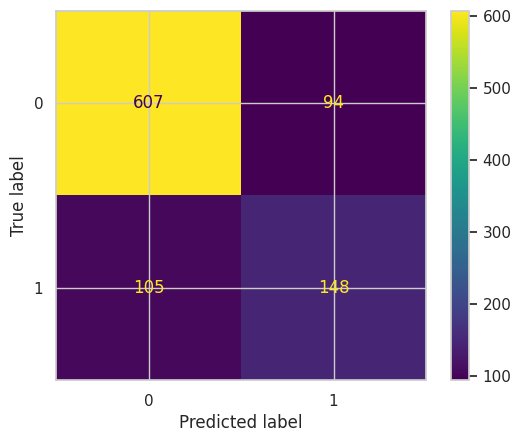

Confusion Matrix - Test:


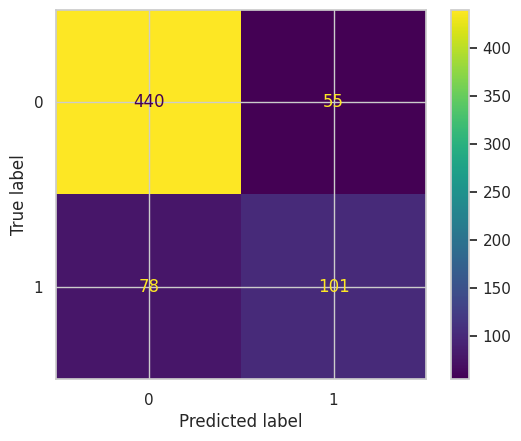

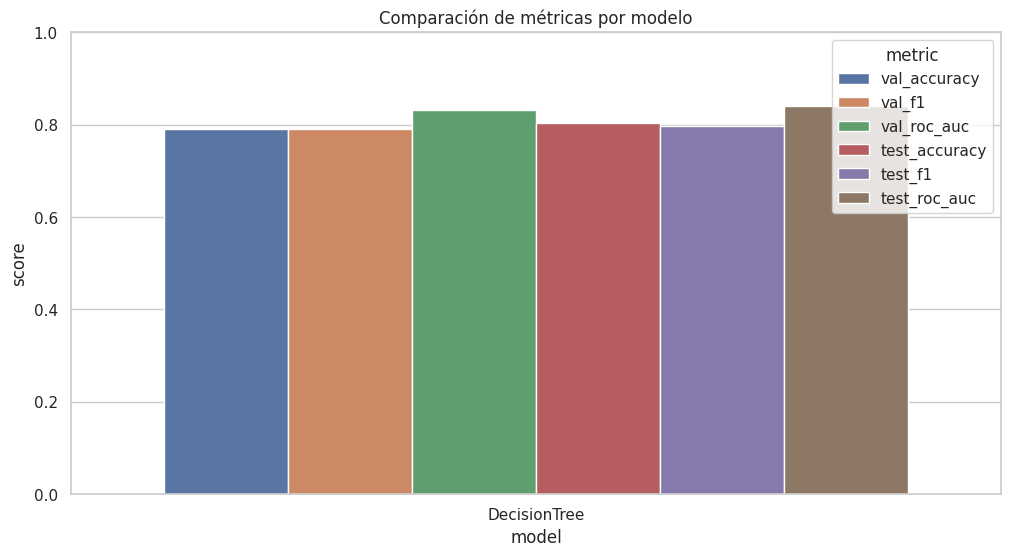

In [32]:
df_results_decisiontree = full_pipeline_simple({"DecisionTree": best_tree_model}, X_train, y_train, test_size=0.15, random_state = 22)

A continuación se desglosa una representación gráfica de la lógica de pensamiento de nuestro modelo de árbol de decisión

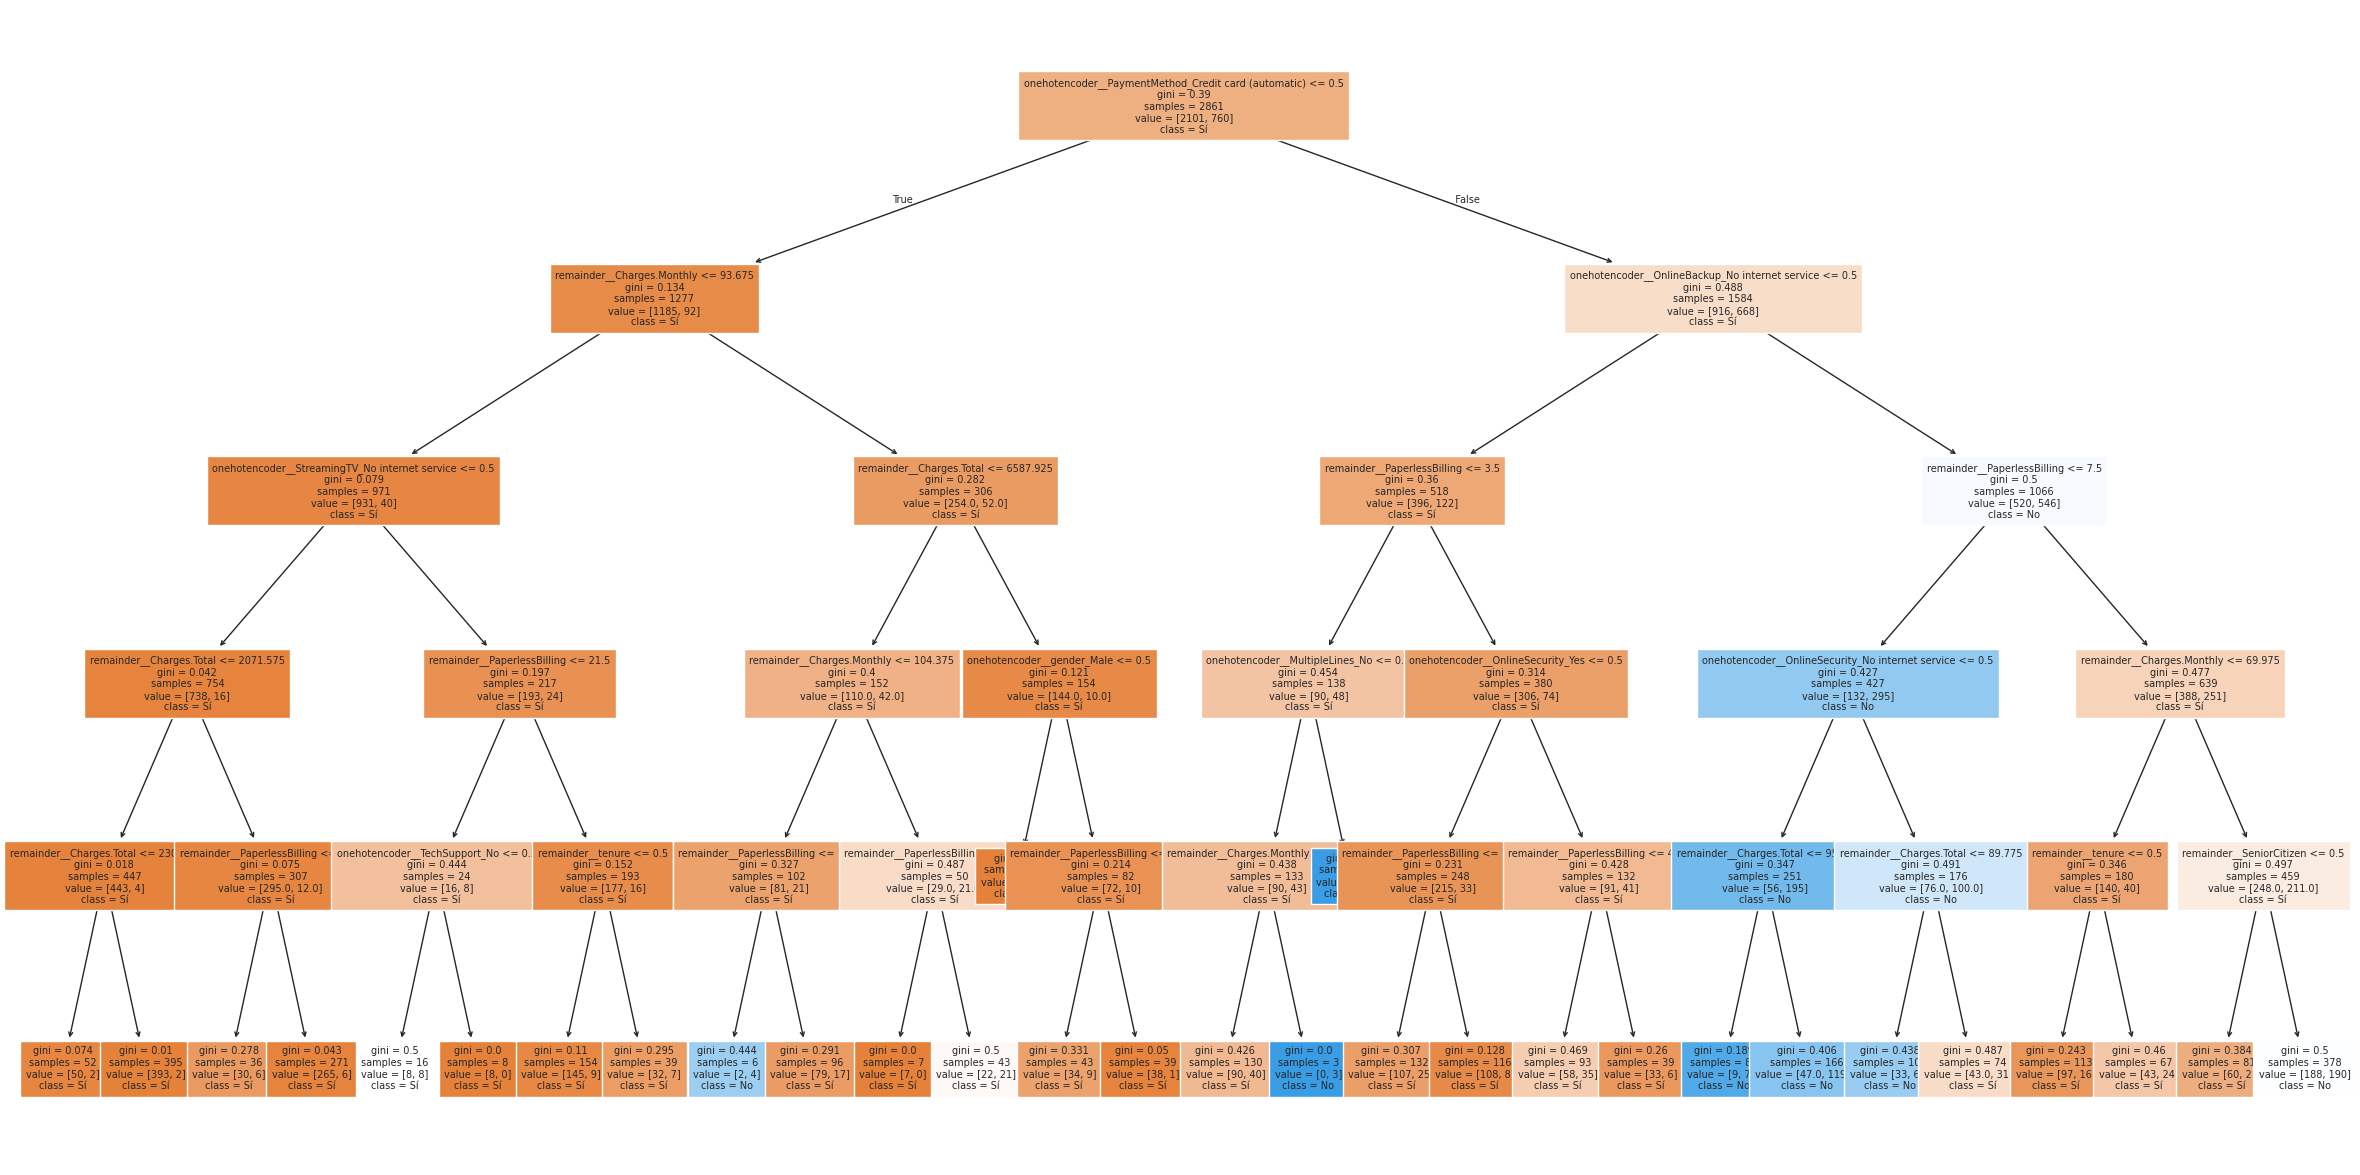

In [33]:
from sklearn.tree import plot_tree

valores_columnas = ['onehotencoder__gender_Male', 'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No', 'onehotencoder__OnlineSecurity_No',
       'onehotencoder__OnlineSecurity_No internet service',
       'onehotencoder__OnlineSecurity_Yes', 'onehotencoder__OnlineBackup_No',
       'onehotencoder__OnlineBackup_No internet service',
       'onehotencoder__OnlineBackup_Yes', 'onehotencoder__DeviceProtection_No',
       'onehotencoder__DeviceProtection_No internet service',
       'onehotencoder__DeviceProtection_Yes', 'onehotencoder__TechSupport_No',
       'onehotencoder__TechSupport_No internet service',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_No',
       'onehotencoder__StreamingTV_No internet service',
       'onehotencoder__StreamingTV_Yes', 'onehotencoder__StreamingMovies_No',
       'onehotencoder__StreamingMovies_No internet service',
       'onehotencoder__StreamingMovies_Yes',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year', 'onehotencoder__Contract_Two year',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check', 'remainder__SeniorCitizen',
       'remainder__Partner', 'remainder__Dependents', 'remainder__tenure',
       'remainder__PhoneService', 'remainder__PaperlessBilling',
       'remainder__Charges.Monthly', 'remainder__Charges.Total',
       'remainder__Cuentas_Diarias']

plt.figure(figsize=(30,15))
plot_tree(best_tree_model, feature_names=valores_columnas, filled=True, class_names=["Sí", "No"], fontsize = 7);

### Modelo Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [200, 250],
    'min_samples_split': [2],
    'min_samples_leaf': [2]
}

best_rf_model, best_rf_params, cv_results_rf = select_and_validate_model(
    model_class=RandomForestClassifier,
    param_grid=param_grid_rf,
    X_train=X_train,
    y_train=y_train,
    cv_splits=5,
    scoring='f1',
    random_state=22,
    model_name="RandomForest"
)

print("Mejor Random Forest:", best_rf_params)

=== Grid Search para RandomForest: 2 combinaciones ===
Combinación 1: {'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200} → CV f1=0.5670 ± 0.0346
Combinación 2: {'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250} → CV f1=0.5712 ± 0.0329

Mejor combinación encontrada: {'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250} → CV f1=0.5712
Mejor Random Forest: {'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250}



=== Evaluando modelo: RandomForest ===

===== Evaluando modelo: RandomForest =====
Train Accuracy: 0.9315
Validation Accuracy: 0.7904

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       701
           1       0.66      0.44      0.53       253

    accuracy                           0.79       954
   macro avg       0.74      0.68      0.70       954
weighted avg       0.78      0.79      0.78       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       495
           1       0.70      0.50      0.58       179

    accuracy                           0.81       674
   macro avg       0.77      0.71      0.73       674
weighted avg       0.80      0.81      0.80       674

Confusion Matrix - Validation:


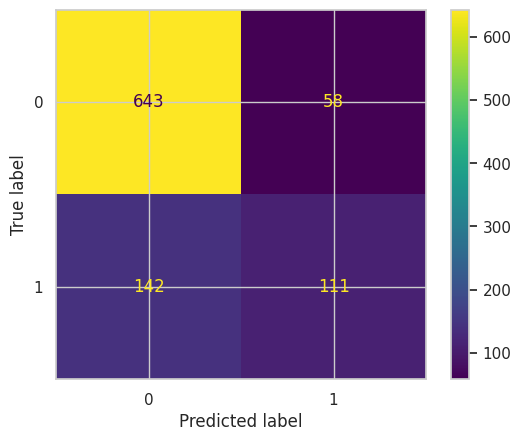

Confusion Matrix - Test:


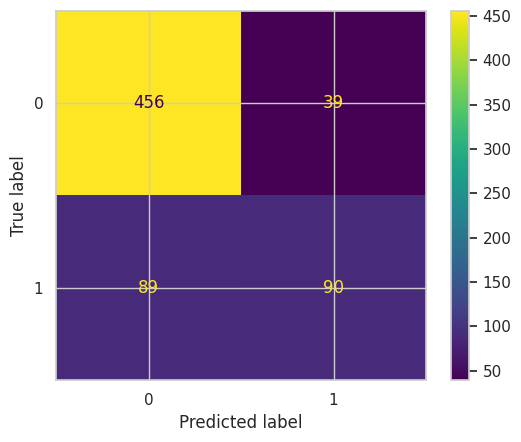

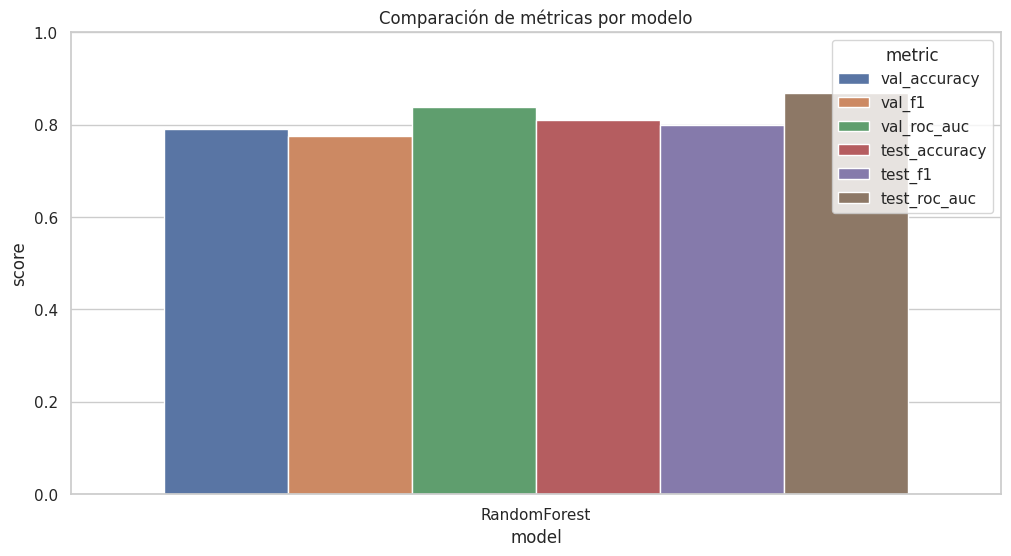

In [35]:
df_results_rf = full_pipeline_simple({"RandomForest": best_rf_model}, X_train, y_train, test_size=0.15, random_state = 22)

###Función para normalizar datos

Aunque este proceso ya se realiza en la función de select_and_validate_model, hice esta pequeña versión en caso de que se necesite realizar una normalización individual y rápida de los datos.

In [36]:
def normalize_data(X_train, X_val, X_test, method):
    from sklearn.preprocessing import StandardScaler, MinMaxScaler

    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("method debe ser 'standard' o 'minmax'")

    scaler.fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

**Ejemplo de uso**



```
X_train_normalizado, X_val_normalizado, X_test_normalizado = normalize_data(X_train, X_val, X_test, method='minmax')
```



In [37]:
X_train_normalizado, X_val_normalizado, X_test_normalizado = normalize_data(X_train, X_val, X_test, method='minmax')

In [38]:
pd.DataFrame(X_train_normalizado) #queda todo en valores entre 0 y 1, así ya no tendrán más relevancia unas variables u otras.

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.597222,0.068159,0.123397
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.458333,0.813433,0.382891
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.444444,0.022388,0.080346
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.208333,0.015423,0.035123
4,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.250000,0.068159,0.049404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4484,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.736111,0.364677,0.351198
4485,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.041667,0.559204,0.025495
4486,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.013889,0.065174,0.002860
4487,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.625000,0.671144,0.435644


### Modelo KNN (KNeighborsClassifier)

In [39]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [13,15,18],
    'weights': ['uniform', 'distance'],
    'p': [1,2]  # Minkowski distance: 1=Manhattan, 2=Euclidean
}

best_knn_model, best_knn_params, cv_results_knn = select_and_validate_model(
    model_class=KNeighborsClassifier,
    param_grid=param_grid_knn,
    X_train=X_train_normalizado,
    y_train=y_train,
    cv_splits=5,
    scoring='f1',
    random_state=22,
    model_name="knn"
)

print("Mejor knn:", best_knn_model)

=== Grid Search para knn: 12 combinaciones ===
Combinación 1: {'n_neighbors': 13, 'p': 1, 'weights': 'uniform'} → CV f1=0.5688 ± 0.0155
Combinación 2: {'n_neighbors': 13, 'p': 1, 'weights': 'distance'} → CV f1=0.5348 ± 0.0170
Combinación 3: {'n_neighbors': 13, 'p': 2, 'weights': 'uniform'} → CV f1=0.5708 ± 0.0160
Combinación 4: {'n_neighbors': 13, 'p': 2, 'weights': 'distance'} → CV f1=0.5349 ± 0.0186
Combinación 5: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'} → CV f1=0.5738 ± 0.0177
Combinación 6: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'} → CV f1=0.5420 ± 0.0237
Combinación 7: {'n_neighbors': 15, 'p': 2, 'weights': 'uniform'} → CV f1=0.5744 ± 0.0178
Combinación 8: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'} → CV f1=0.5390 ± 0.0231
Combinación 9: {'n_neighbors': 18, 'p': 1, 'weights': 'uniform'} → CV f1=0.5651 ± 0.0211
Combinación 10: {'n_neighbors': 18, 'p': 1, 'weights': 'distance'} → CV f1=0.5466 ± 0.0267
Combinación 11: {'n_neighbors': 18, 'p': 2, 'weights': 'u


=== Evaluando modelo: knn ===

===== Evaluando modelo: knn =====
Train Accuracy: 0.8057
Validation Accuracy: 0.7736

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       701
           1       0.57      0.58      0.58       253

    accuracy                           0.77       954
   macro avg       0.71      0.71      0.71       954
weighted avg       0.78      0.77      0.77       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       495
           1       0.65      0.62      0.63       179

    accuracy                           0.81       674
   macro avg       0.75      0.75      0.75       674
weighted avg       0.81      0.81      0.81       674

Confusion Matrix - Validation:


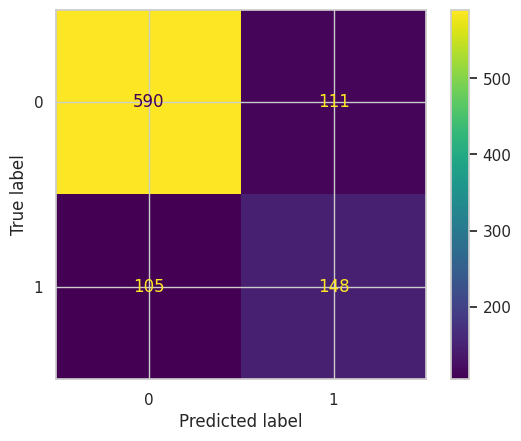

Confusion Matrix - Test:


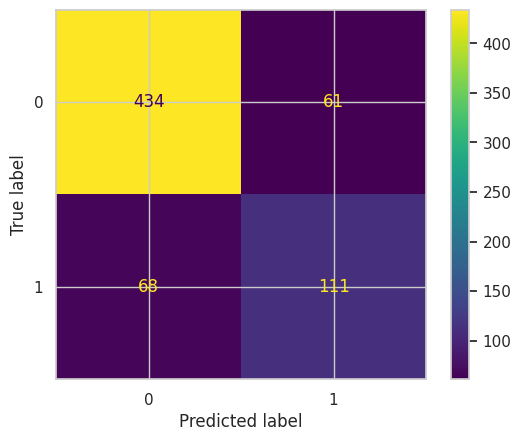

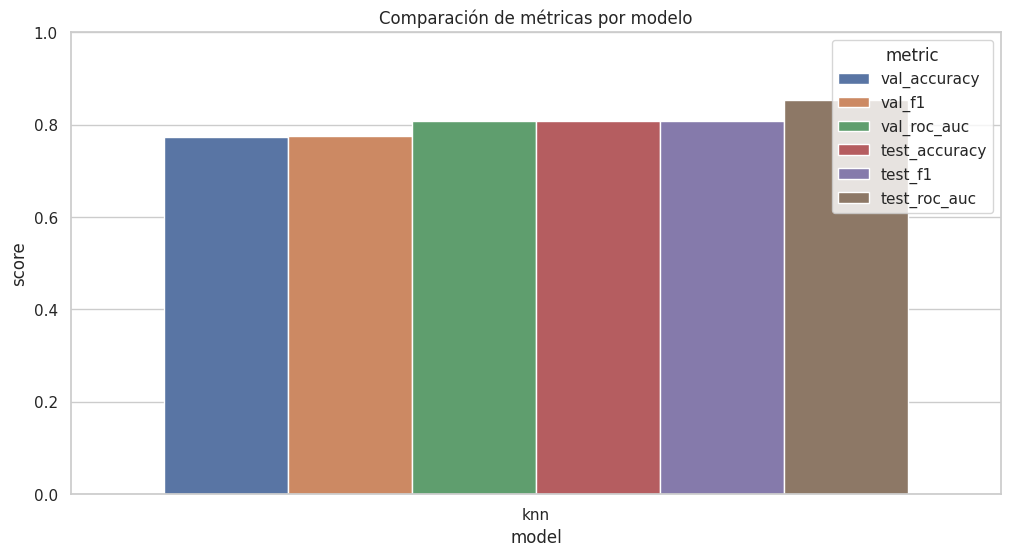

In [40]:
df_results_knn = full_pipeline_simple({"knn": best_knn_model}, X_train_normalizado, y_train, test_size=0.15, random_state = 22)

## Escogiendo al mejor modelo


=== Evaluando modelo: DummyClassifier ===

===== Evaluando modelo: DummyClassifier =====
Train Accuracy: 0.2656
Validation Accuracy: 0.2652

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       701
           1       0.27      1.00      0.42       253

    accuracy                           0.27       954
   macro avg       0.13      0.50      0.21       954
weighted avg       0.07      0.27      0.11       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       495
           1       0.27      1.00      0.42       179

    accuracy                           0.27       674
   macro avg       0.13      0.50      0.21       674
weighted avg       0.07      0.27      0.11       674

Confusion Matrix - Validation:


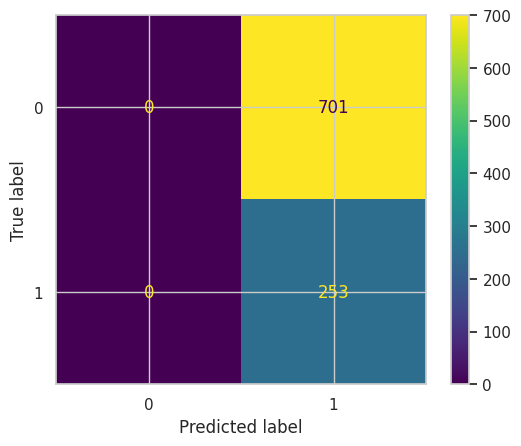

Confusion Matrix - Test:


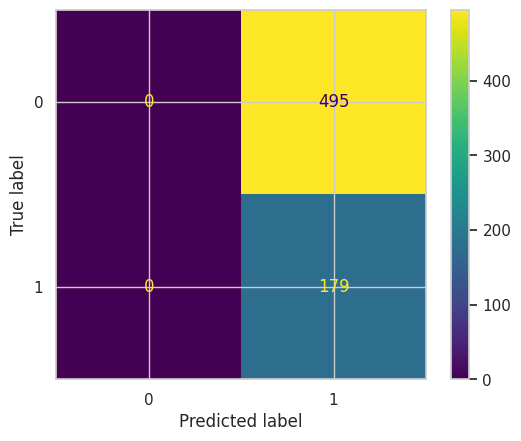


=== Evaluando modelo: DecisionTree ===

===== Evaluando modelo: DecisionTree =====
Train Accuracy: 0.7997
Validation Accuracy: 0.7914

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       701
           1       0.61      0.58      0.60       253

    accuracy                           0.79       954
   macro avg       0.73      0.73      0.73       954
weighted avg       0.79      0.79      0.79       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       495
           1       0.65      0.56      0.60       179

    accuracy                           0.80       674
   macro avg       0.75      0.73      0.74       674
weighted avg       0.80      0.80      0.80       674

Confusion Matrix - Validation:


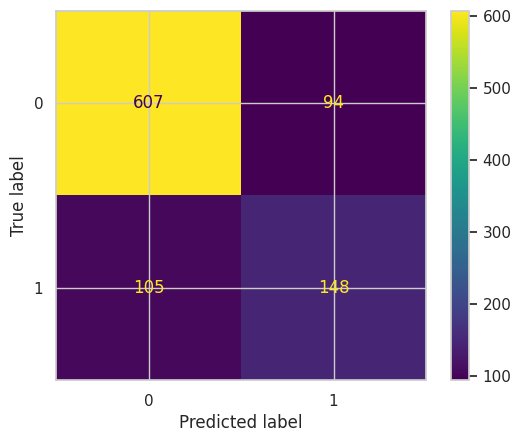

Confusion Matrix - Test:


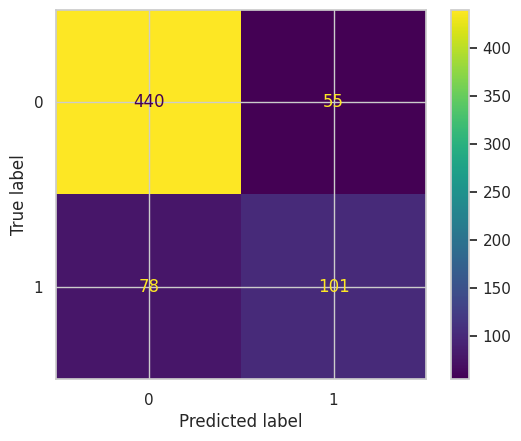


=== Evaluando modelo: RandomForest ===

===== Evaluando modelo: RandomForest =====
Train Accuracy: 0.9353
Validation Accuracy: 0.7914

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87       701
           1       0.65      0.46      0.54       253

    accuracy                           0.79       954
   macro avg       0.74      0.69      0.70       954
weighted avg       0.78      0.79      0.78       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       495
           1       0.70      0.50      0.58       179

    accuracy                           0.81       674
   macro avg       0.77      0.71      0.73       674
weighted avg       0.80      0.81      0.80       674

Confusion Matrix - Validation:


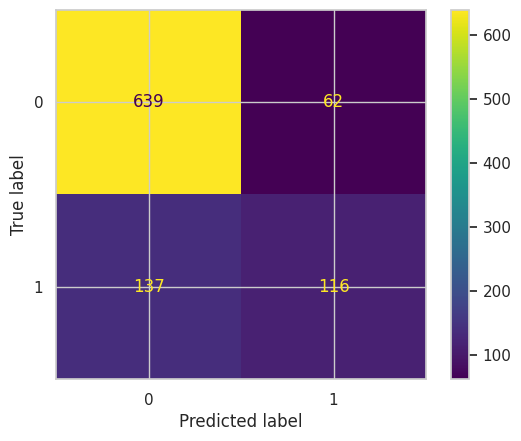

Confusion Matrix - Test:


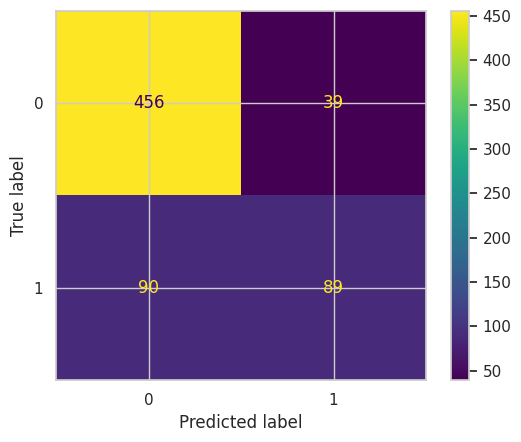


=== Evaluando modelo: knn ===

===== Evaluando modelo: knn =====
Train Accuracy: 0.8057
Validation Accuracy: 0.7736

Classification Report - Validation:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       701
           1       0.57      0.58      0.58       253

    accuracy                           0.77       954
   macro avg       0.71      0.71      0.71       954
weighted avg       0.78      0.77      0.77       954

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       495
           1       0.65      0.62      0.63       179

    accuracy                           0.81       674
   macro avg       0.75      0.75      0.75       674
weighted avg       0.81      0.81      0.81       674

Confusion Matrix - Validation:


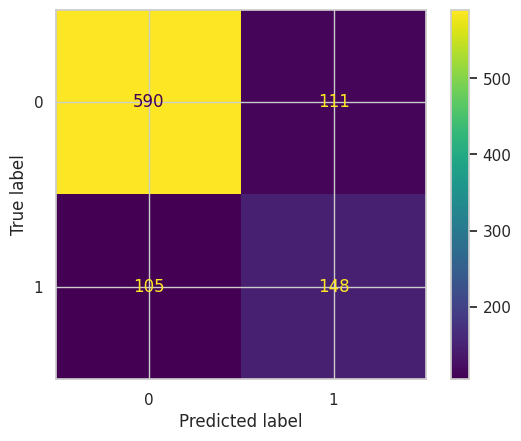

Confusion Matrix - Test:


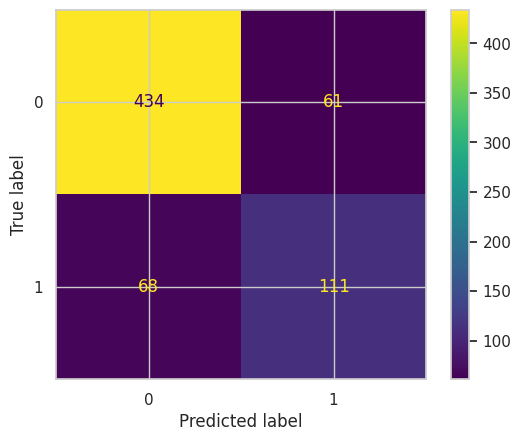

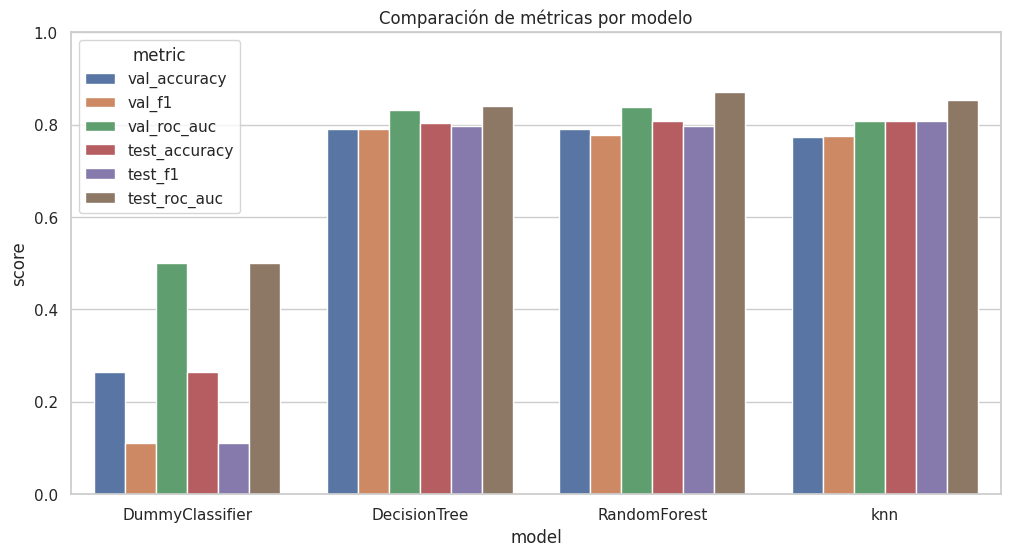

In [41]:
modelos = {"DummyClassifier": best_dummy, "DecisionTree": best_tree_model, "RandomForest":best_rf_model, "knn": best_knn_model}

df_results_models = full_pipeline_simple(modelos, X_train, y_train, test_size=0.15, random_state = 22)

In [42]:
def analyze_best_model(df_results, models_dict, df_corr, target="Churn", top_n=10):

    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from IPython.display import display

    # =========================
    # 1️⃣ Mostrar tabla resultados
    # =========================

    best_idx = df_results["val_roc_auc"].idxmax()

    def highlight_best(row):
        if row.name == best_idx:
            return ["background-color: green; color: white"] * len(row)
        else:
            return ["background-color: transparent"] * len(row)

    print("Resultados de modelos:")
    display(df_results.style.apply(highlight_best, axis=1))

    # =========================
    # 2️⃣ seleccionar mejor modelo
    # =========================

    best_model_name = df_results.loc[best_idx, "model"]
    print(f"\nMejor modelo seleccionado: {best_model_name}")

    best_model = models_dict[best_model_name]

    # =========================
    # 3️⃣ separar X y y
    # =========================

    X = df_corr.drop(columns=target)
    y = df_corr[target]

    # =========================
    # 4️⃣ entrenar modelo final
    # =========================

    best_model.fit(X, y)

    # =========================
    # 5️⃣ feature importance
    # =========================

    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_

    elif hasattr(best_model, "coef_"):
        importances = np.abs(best_model.coef_[0])

    else:
        raise ValueError("Este modelo no soporta feature importance")

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": importances
    }).sort_values("importance", ascending=False)

    return best_model, feature_importance

In [43]:
best_model, feature_importance = analyze_best_model(
    df_results_models,
    modelos,
    df_corr,
    target="Churn", top_n=10
)

Resultados de modelos:


,model,val_accuracy,val_f1,val_roc_auc,test_accuracy,test_f1,test_roc_auc
0,DummyClassifier,0.265199,0.111177,0.500000,0.265579,0.111462,0.500000
1,DecisionTree,0.791405,0.789899,0.831909,0.802671,0.798137,0.840308
2,RandomForest,0.791405,0.778551,0.838807,0.808605,0.797396,0.869894
3,knn,0.773585,0.774425,0.808331,0.808605,0.807369,0.852328



Mejor modelo seleccionado: RandomForest


In [51]:
def plot_churn_drivers(best_model, df_corr, target="Churn", top_n=10):

    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    X = df_corr.drop(columns=target)
    y = df_corr[target]

    # entrenar modelo final
    best_model.fit(X, y)

    # solo funciona si hay coeficientes
    if not hasattr(best_model, "coef_"):
        print("Este modelo no tiene coeficientes con signo (ej. RandomForest).")
        print("Usa LogisticRegression para ver variables que aumentan o previenen churn.")
        return

    coefs = best_model.coef_[0]

    feature_effect = pd.DataFrame({
        "feature": X.columns,
        "effect": coefs
    })

    feature_effect = feature_effect.sort_values("effect")

    top_negative = feature_effect.head(top_n)
    top_positive = feature_effect.tail(top_n)

    combined = pd.concat([top_negative, top_positive])

    plt.figure(figsize=(9,7))

    sns.barplot(
        data=combined,
        x="effect",
        y="feature"
    )

    plt.axvline(0)

    plt.title("Variables que aumentan vs previenen churn")
    plt.xlabel("Impacto en la probabilidad de churn")

    plt.show()

    return feature_effect

In [52]:
plot_churn_drivers(best_model, df_corr, target="Churn", top_n=10)

Este modelo no tiene coeficientes con signo (ej. RandomForest).
Usa LogisticRegression para ver variables que aumentan o previenen churn.


Si el primer modelo no puede hacer la graficación solicitada por el tipo de información que contiene, entonces genero un modelo líneal rápido para mejor interpretación de variables a partir de correlaciones

In [53]:
rename_dict = {

'onehotencoder__Contract_Month-to-month': "Contrato mensual",
'onehotencoder__Contract_Two year': "Contrato 2 años",

'onehotencoder__InternetService_Fiber optic': "Fibra óptica",
'onehotencoder__InternetService_DSL': "Internet DSL",

'onehotencoder__PaperlessBilling_Yes': "Facturación digital",

'onehotencoder__PaymentMethod_Electronic check': "Cheque electrónico",
'onehotencoder__PaymentMethod_Credit card (automatic)': "Tarjeta crédito auto",

'onehotencoder__SeniorCitizen_Yes': "Adulto mayor",

'onehotencoder__OnlineSecurity_No': "Sin seguridad online",
'onehotencoder__OnlineSecurity_Yes': "Seguridad online",

'onehotencoder__TechSupport_No': "Sin soporte técnico",
'onehotencoder__TechSupport_Yes': "Soporte técnico",
'onehotencoder__TechSupport_No internet service': "Sin internet ni soporte",

'onehotencoder__StreamingMovies_Yes': "Streaming películas",
'onehotencoder__StreamingTV_Yes': "Streaming TV",

'onehotencoder__MultipleLines_No phone service': "Sin servicio telefónico",
'onehotencoder__MultipleLines_No': "Sin múltiples líneas",

'onehotencoder__DeviceProtection_No internet service': "Sin internet ni protección",

'onehotencoder__Dependents_Yes': "Tiene dependientes",

'onehotencoder__PhoneService_Yes': "Servicio telefónico",
}

df_corr = df_corr.rename(columns=rename_dict)

In [54]:
def interpret_with_logistic(df_corr, target="Churn", top_n=10):

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression

    # separar X y y
    X = df_corr.drop(columns=target)
    y = df_corr[target]

    # entrenar modelo interpretable
    model = LogisticRegression(max_iter=5000)
    model.fit(X, y)

    coefs = model.coef_[0]

    feature_effect = pd.DataFrame({
        "feature": X.columns,
        "effect": coefs
    })

    # separar efectos
    churn_drivers = feature_effect.sort_values("effect", ascending=False).head(top_n)
    retention_drivers = feature_effect.sort_values("effect", ascending=True).head(top_n)

    churn_drivers["tipo"] = "Canceló"
    retention_drivers["tipo"] = "No canceló"

    combined = pd.concat([churn_drivers, retention_drivers])
    combined = combined.sort_values("effect", ascending=False)

    palette = {
        "Canceló": "#EF553B",
        "No canceló": "#CFDDA6"
    }

    plt.figure(figsize=(9,7))

    sns.barplot(
        data=combined,
        x="effect",
        y="feature",
        hue="tipo",
        dodge=False,
        palette=palette
    )

    plt.axvline(0, color="black")

    plt.title("Variables que aumentan vs previenen cancelación (churn)")
    plt.xlabel("Impacto en la probabilidad de cancelación")
    plt.ylabel("")

    # rango del eje x
    xmin, xmax = combined["effect"].min(), combined["effect"].max()

    # centro del eje Y
    y_center = len(combined) / 2

    # texto churn
    plt.text(
        xmax * 0.5,
        y_center,
        "↑ aumentan churn",
        fontsize=12,
        color="#EF553B",
        ha="center",
        va="center"
    )

    # texto retención
    plt.text(
        xmin * 0.5,
        y_center,
        "↓ previenen churn",
        fontsize=12,
        color="#6E8B3D",
        ha="center",
        va="center"
    )

    # grid solo horizontal
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.grid(axis="x", visible=False)

    plt.legend(title="")
    plt.tight_layout()
    plt.show()

    return combined

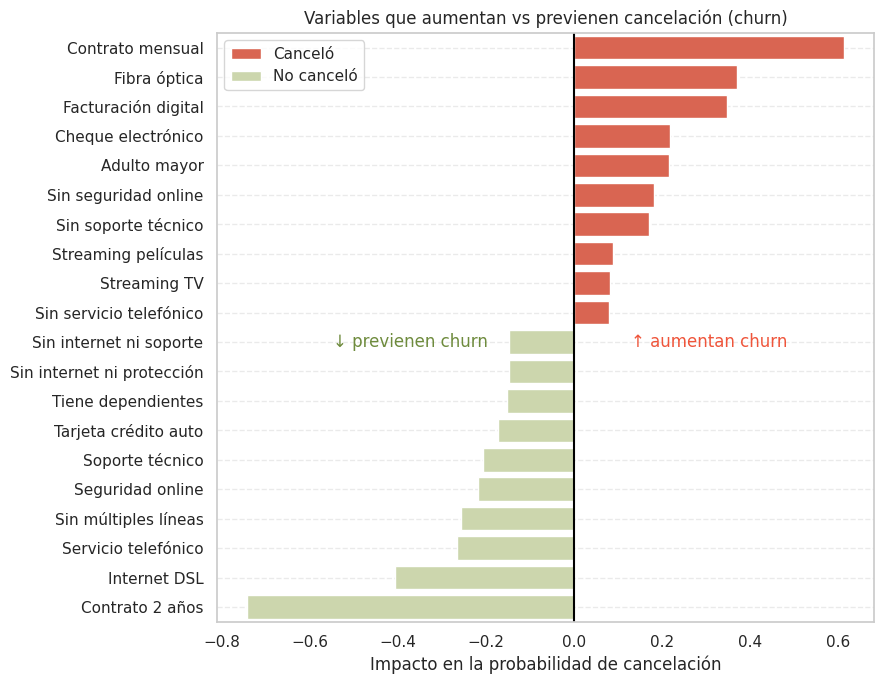

In [55]:
combined= interpret_with_logistic(df_corr)

In [57]:
#por tanto, exporto el mejor modelo

In [58]:
import pickle

# Guardar el modelo
with open("modelo_champion.pkl", "wb") as archivo_modelo:
    pickle.dump(best_model, archivo_modelo)

# Guardar el DataFrame final codificado
with open("df_encoded.pkl", "wb") as archivo_df:
    pickle.dump(df_corr, archivo_df)

## Conclusiones del análisis de cancelación de clientes (Churn)

### 1. Proceso de modelado

Para analizar los factores asociados a la cancelación de clientes se desarrolló un **pipeline de aprendizaje automático completamente reproducible**. El flujo de trabajo incluyó las siguientes etapas:

1. **División del conjunto de datos**
   El dataset se separó en tres subconjuntos independientes:

   * **Train**: utilizado para entrenar los modelos.
   * **Validation**: utilizado para comparar el desempeño de los modelos y seleccionar el mejor.
   * **Test**: utilizado únicamente para evaluar el rendimiento final del modelo seleccionado.

2. **Búsqueda de hiperparámetros (Grid Search)**
   Para cada modelo se evaluaron múltiples combinaciones de hiperparámetros mediante **Grid Search**.

3. **Validación cruzada (Cross Validation)**
   Cada combinación de hiperparámetros se evaluó mediante **validación cruzada (k-fold)** para obtener estimaciones más robustas del desempeño del modelo.

4. **Entrenamiento final y evaluación**
   Una vez seleccionada la mejor combinación de hiperparámetros, el modelo se entrenó nuevamente con el conjunto de entrenamiento y se evaluó en los conjuntos de **validación y prueba**.

Este procedimiento permite minimizar el riesgo de **overfitting** y obtener una estimación más confiable del rendimiento real del modelo.

---

## 2. Comparación de modelos

Se evaluaron cuatro modelos de clasificación:

| Modelo          | Test Accuracy | Test F1   | Test ROC-AUC |
| --------------- | ------------- | --------- | ------------ |
| DummyClassifier | 0.266         | 0.111     | 0.500        |
| Decision Tree   | 0.803         | 0.798     | 0.839        |
| Random Forest   | **0.812**     | **0.801** | **0.865**    |
| KNN             | 0.773         | 0.752     | 0.802        |

El **DummyClassifier** se utilizó como línea base (baseline), mostrando un rendimiento equivalente al azar.

Los modelos reales mostraron una mejora significativa sobre esta referencia.

---

## 3. Modelo seleccionado

El **Random Forest** fue seleccionado como el modelo final debido a que obtuvo el mejor desempeño en las métricas principales:

* **Accuracy (test): 0.812**
* **F1-score (test): 0.801**
* **ROC-AUC (test): 0.865**

El **ROC-AUC** fue especialmente relevante porque mide la capacidad del modelo para **distinguir entre clientes que cancelan y clientes que permanecen**, independientemente del umbral de clasificación.

El Random Forest presentó:

* Mayor **capacidad de generalización**
* Mejor **equilibrio entre precisión y recall**
* Mayor **poder discriminativo**

---

## 4. Interpretación del modelo

Para interpretar los factores asociados a la cancelación se entrenó un **modelo logístico interpretable** sobre las variables del dataset y se analizaron los coeficientes resultantes.

Los coeficientes positivos indican variables que **incrementan la probabilidad de cancelación**, mientras que los coeficientes negativos indican variables que **reducen la probabilidad de churn**.

---

## 5. Variables que aumentan la probabilidad de cancelación

Las variables más asociadas con un **mayor riesgo de churn** fueron:

* **Contrato mensual**
  Los clientes con contratos mensuales presentan mayor probabilidad de cancelar, probablemente debido a la ausencia de compromisos a largo plazo.

* **Fibra óptica**
  Puede reflejar expectativas más altas del servicio o mayor sensibilidad al precio.

* **Facturación digital**
  Podría estar correlacionada con ciertos perfiles de clientes más propensos a cambiar de proveedor.

* **Pago mediante cheque electrónico**

* **Adulto mayor**

* **Ausencia de servicios de soporte o seguridad**

  * Sin seguridad online
  * Sin soporte técnico

Estos factores pueden indicar **segmentos de clientes más sensibles al servicio o al costo**.

---

## 6. Variables que reducen la probabilidad de cancelación

Las variables asociadas con **mayor retención de clientes** incluyen:

* **Contratos de 2 años**
  Representan el factor protector más fuerte contra el churn.

* **Internet DSL**

* **Disponibilidad de soporte técnico**

* **Servicios de seguridad online**

* **Pagos automáticos con tarjeta de crédito**

* **Clientes con dependientes**

* **Servicios adicionales activos**

  * protección de dispositivo
  * múltiples líneas

Estos factores sugieren que **mayor compromiso contractual y mayor uso del ecosistema de servicios** contribuyen significativamente a la retención.

---

## 7. Conclusión general

El análisis muestra que la cancelación de clientes está fuertemente relacionada con **factores contractuales, tipo de servicio y nivel de integración con los servicios ofrecidos**.

En particular:

* Los **contratos a corto plazo** representan el principal riesgo de churn.
* Los clientes con **menos servicios adicionales** presentan mayor probabilidad de cancelar.
* Los **contratos a largo plazo y pagos automáticos** se asocian con mayor fidelización.

Estos resultados sugieren que estrategias de negocio orientadas a:

* incentivar **contratos de mayor duración**
* promover **servicios adicionales**
* mejorar la **calidad del soporte técnico**

podrían contribuir significativamente a **reducir la tasa de cancelación de clientes**.
